# Ejercicio 9

In [1]:
import numpy as np
import matplotlib.pyplot as plt

Valor Verdadero de λ: 0.5000
Tiempo promedio de decaimiento: 2.5814 s
----------------------------------------
Estimación Frecuentista (MLE): λ = 0.3874
Estimación Bayesiana (Media Posterior): λ = 0.3951


/tmp/ipykernel_36554/4134890091.py:25: RuntimeWarning: divide by zero encountered in log
  log_posterior = n_mediciones * np.log(lambda_grid) - lambda_grid * suma_de_tiempos
/tmp/ipykernel_36554/4134890091.py:28: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  posterior /= np.trapz(posterior, lambda_grid)


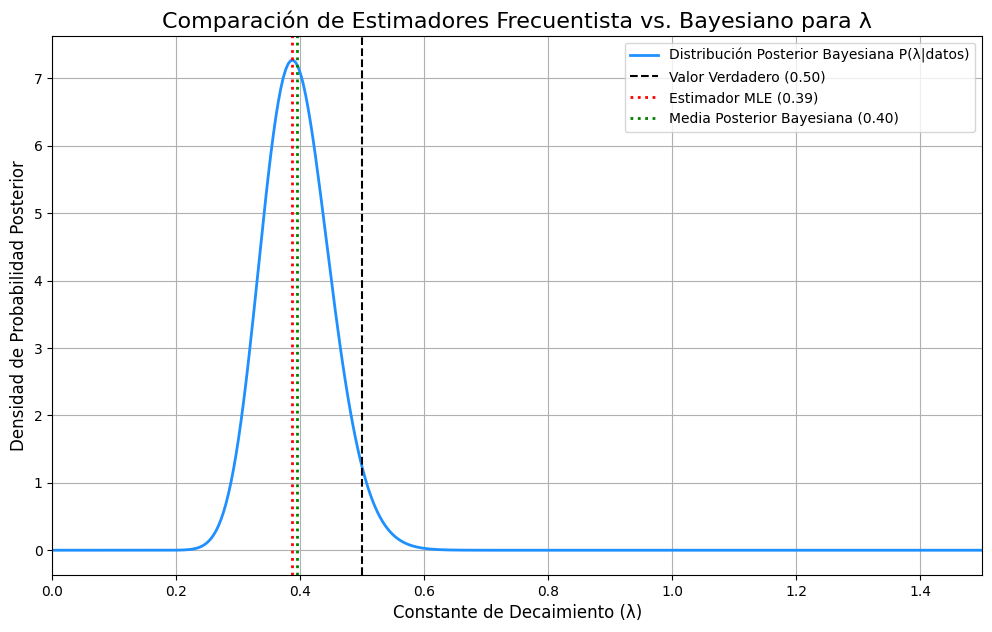

In [2]:
# --- 1. Simular los datos ---
# Primero, necesitamos un valor "verdadero" de lambda para generar los datos.
# Este valor es desconocido para el análisis, pero necesario para la simulación.
lambda_verdadero = 0.5  # Constante de decaimiento real (ejemplo)
n_mediciones = 50

# El scale para la distribución exponencial en numpy es 1/lambda.
# Simulamos 50 tiempos de decaimiento.
tiempos_simulados = np.random.exponential(scale=1/lambda_verdadero, size=n_mediciones)

# --- 2. Estimar lambda con Máxima Verosimilitud (Frecuentista) ---
tiempo_promedio = np.mean(tiempos_simulados)
lambda_mle = 1 / tiempo_promedio

# --- 3. Estimar lambda con Inferencia Bayesiana ---
# El estimador bayesiano que usaremos es la media de la distribución posterior.
suma_de_tiempos = np.sum(tiempos_simulados)
lambda_bayes_mean = (n_mediciones + 1) / suma_de_tiempos

# Para visualizar, calculamos la distribución posterior completa.
# La forma es P(λ|datos) ∝ λ^N * exp(-λ * Σt)
# Creamos una grilla de posibles valores de lambda para graficar.
lambda_grid = np.linspace(0, 2.0, 500)
# Calculamos el log-posterior para evitar problemas numéricos
log_posterior = n_mediciones * np.log(lambda_grid) - lambda_grid * suma_de_tiempos
# Convertimos de nuevo a la escala normal y normalizamos para que el área sea 1.
posterior = np.exp(log_posterior - np.max(log_posterior))
posterior /= np.trapz(posterior, lambda_grid)

# --- 4. Comparar las estimaciones ---
print(f"Valor Verdadero de λ: {lambda_verdadero:.4f}")
print(f"Tiempo promedio de decaimiento: {tiempo_promedio:.4f} s")
print("-" * 40)
print(f"Estimación Frecuentista (MLE): λ = {lambda_mle:.4f}")
print(f"Estimación Bayesiana (Media Posterior): λ = {lambda_bayes_mean:.4f}")

# --- Graficar los resultados ---
plt.figure(figsize=(12, 7))
plt.plot(lambda_grid, posterior, label='Distribución Posterior Bayesiana P(λ|datos)', color='dodgerblue', lw=2)
plt.axvline(lambda_verdadero, color='black', linestyle='--', label=f'Valor Verdadero ({lambda_verdadero:.2f})')
plt.axvline(lambda_mle, color='red', linestyle=':', label=f'Estimador MLE ({lambda_mle:.2f})', lw=2)
plt.axvline(lambda_bayes_mean, color='green', linestyle=':', label=f'Media Posterior Bayesiana ({lambda_bayes_mean:.2f})', lw=2)

plt.title('Comparación de Estimadores Frecuentista vs. Bayesiano para λ', fontsize=16)
plt.xlabel('Constante de Decaimiento (λ)', fontsize=12)
plt.ylabel('Densidad de Probabilidad Posterior', fontsize=12)
plt.legend()
plt.grid(True)
plt.xlim(0, 1.5) # Ajustar límites para mejor visualización
plt.show()